Exploatory Data Analisis

Primero si el kernel falla, seguir estos pasos:
 - removed el viejo venv: rm -rf .venv
 - crear un nuevo venv: uv venv
 - instalar dependencias: <br>
     uv pip install numpy pandas matplotlib seaborn scikit-learnpathlib
 - reiniciar visual studio
 - aceptar la instalacion de ipykernel

In [87]:
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler,TargetEncoder, LabelEncoder, PowerTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, root_mean_squared_error, ConfusionMatrixDisplay,classification_report, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [88]:


#ROOT_DIR = Path().resolve().parent.parent
#DATA_DIR = ROOT_DIR / "data/raw"
#file_path = 'Telco_customer_churn.csv'

#Leer el archivo csv con pandas
#df = pd.read_csv(DATA_DIR / file_path, header=0, na_values=[' '])
df = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data",
    header=None,
    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship',
           'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'])
#Mostrar las 5 primeras filas del dataframe
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [89]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [90]:
#metricas de las variables numericas
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [91]:
#metricas de las variables categoricas
df.describe(include='object')

/tmp/ipykernel_280684/3586772019.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [92]:
# porcentaje de valores nulos
df.isnull().sum().sort_values(ascending=False)*100/df.shape[0]

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education-num     0.0
marital-status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital-gain      0.0
capital-loss      0.0
hours-per-week    0.0
native-country    0.0
income            0.0
dtype: float64

<p style='color:blue'> si se requiere hacer interpolacion de datos referirse al archivo *Preparacion_de_los_datos_con_pandas*</p>

In [93]:
#Eliminar valores nulos
#df = df.drop(columns=['Churn Reason'])#Elimina de forma permanente la columna
#df = df.dropna(subset=['Total Charges'])#Revisa en la columna 'Total Charges' si hay valores nulos y elimina esas filas.
df.dropna().info()#Elimina las filas que contienen valores nulos y muestra la información del DataFrame resultante.
df.isnull().sum().sort_values(ascending=False)*100/df.shape[0]

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education-num     0.0
marital-status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital-gain      0.0
capital-loss      0.0
hours-per-week    0.0
native-country    0.0
income            0.0
dtype: float64

In [94]:
#filas duplicadas
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  24


In [95]:
#eliminar filas duplicadas
df =  df.drop_duplicates()
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


Analisis de datos numericos

VERIFICACION DE SUPUESTO DE NORMALIDAD

1. **Curtosis normal (mesocúrtica)**
   - Valor de curtosis ≈ 0.
   - La distribución tiene colas similares a las de una distribución normal.
   - Ejemplo: distribución normal estándar.

2. **Curtosis alta (leptocúrtica)**  
   - Valor de curtosis > 0.
   - La distribución tiene colas más pesadas y un pico más alto en el centro.
   - Indica mayor probabilidad de valores extremos (outliers).
   - Ejemplo: distribución t de Student con pocos grados de libertad.

3. **Curtosis baja (platicúrtica)**  
   - Valor de curtosis < 0.
   - La distribución es más plana, con colas más ligeras.
   - Menor probabilidad de valores extremos.
   - Ejemplo: distribución uniforme.

In [96]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Kurtosis de {num}: {df[num].kurt():.3f} \n")

    

Kurtosis de age: -0.170 

Kurtosis de fnlwgt: 6.222 

Kurtosis de education-num: 0.619 

Kurtosis de capital-gain: 154.683 

Kurtosis de capital-loss: 20.358 

Kurtosis de hours-per-week: 2.918 



De aqui las que sean aproximadamente normales van a pasar por StandardScaler. Es decir:
age y education-num, el resto deberia pasar por PowerTransformer

VERIFICACION DE ASIMETRIA

1. **Asimetría positiva (sesgo a la derecha)**  
   - Valor de asimetría > 0  
   - La cola derecha (valores grandes) es más larga o más pesada.  
   - La mayoría de los datos están concentrados en el lado izquierdo de la media.  
   - Ejemplo: ingresos personales (muchos ganan poco, pocos ganan mucho).

2. **Asimetría negativa (sesgo a la izquierda)**  
   - Valor de asimetría < 0  
   - La cola izquierda (valores pequeños) es más larga o más pesada.  
   - La mayoría de los datos están concentrados en el lado derecho de la media.  
   - Ejemplo: edad de jubilación (la mayoría se jubila a una edad similar, pocos lo hacen muy temprano).

3. **Asimetría nula (simétrica)**  
   - Valor de asimetría ≈ 0  
   - La distribución es simétrica respecto a la media.  
   - Ejemplo: distribución normal.

In [97]:
for num in df.select_dtypes(include=['number']).columns:
    print(f"Asimetría de {num}: {df[num].skew():.3f} \n")

Asimetría de age: 0.558 

Asimetría de fnlwgt: 1.448 

Asimetría de education-num: -0.310 

Asimetría de capital-gain: 11.949 

Asimetría de capital-loss: 4.593 

Asimetría de hours-per-week: 0.229 



Identificamos que variables numericas son utiles con la matriz de correlacion

<Axes: >

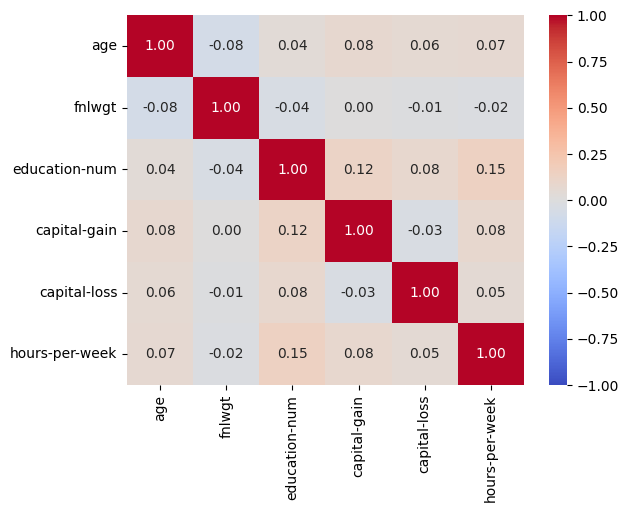

In [98]:
corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

In [99]:
df = df.drop(columns=['capital-loss','fnlwgt','age'])

Identificacion de OUTLIERS Univariados

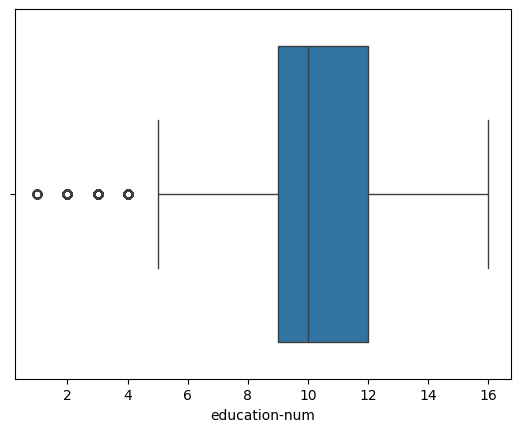

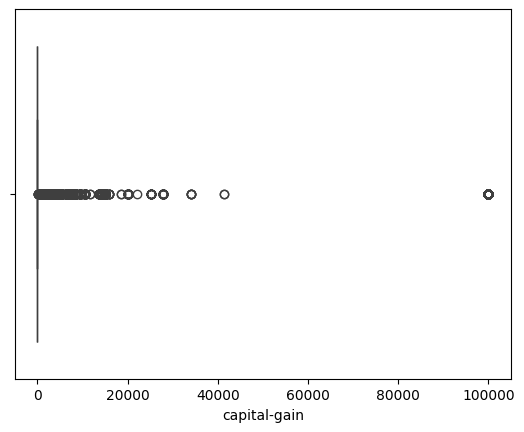

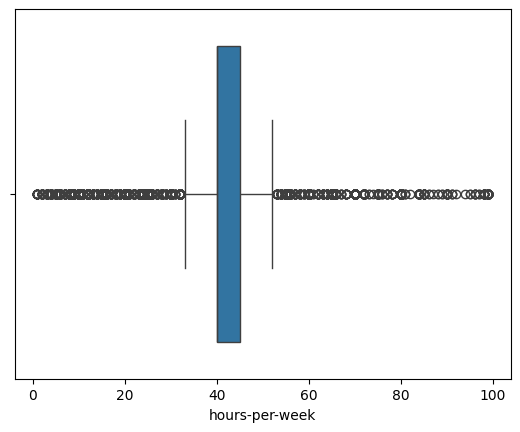

In [100]:
for num in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.boxplot(data=df, x=num)
    plt.show();

Tratamiento de esos outliers

In [101]:
# para las variables con distribucion normal aplicamos Z-score:
print('Número de registros: ', df.shape[0]) # aqui vamos cuantos datos hay antes de

Número de registros:  32537


In [102]:
df1 = df.copy()
df1['z-score'] = (df1['education-num'] - df1['education-num'].mean())/df1['education-num'].std()
df1 = df1[(df1['z-score']<=3)&((df1['z-score']>=-3))]
print('Número de registros: ', df1.shape[0])  #aqui cuantos quedan tras eliminar los outliers

Número de registros:  32321


Damos una ultima revision a las distribuciones de las variables.

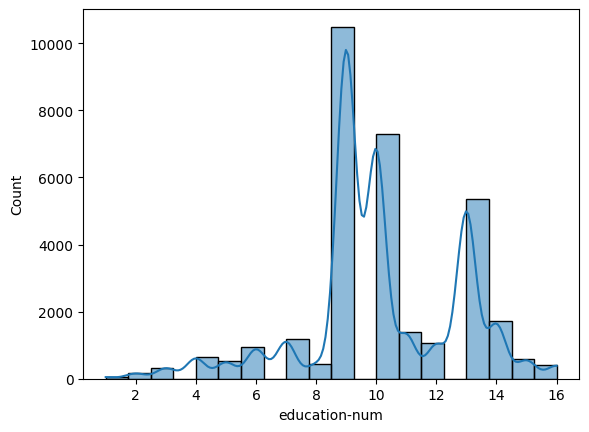

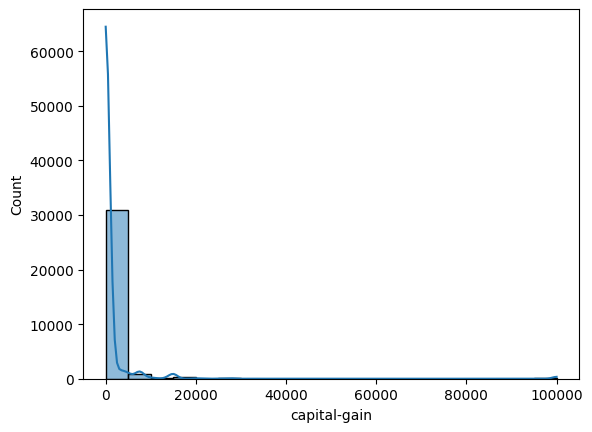

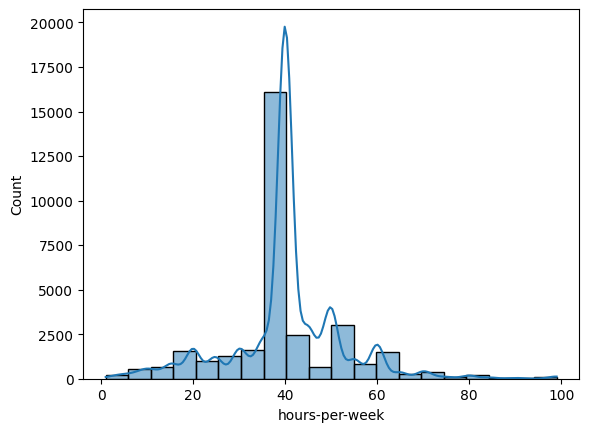

In [103]:

for col in df.select_dtypes(include=['number']).columns:
    plt.figure()
    sns.histplot(data=df, x=col, bins=20, kde=True)
    plt.show()

para capital-gain como es una funcion exponencial le aplicaremos logaritmo.

In [117]:
df['capital-gain_log'] = np.log1p(df['capital-gain']) #si se corre varias veces esta, se aplica varias veces el logaritmo.

array([[<Axes: title={'center': 'capital-gain_log'}>]], dtype=object)

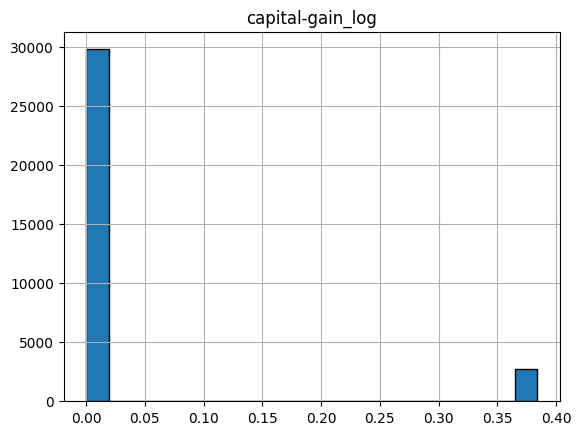

In [130]:
df.hist(column='capital-gain_log', bins=20, edgecolor='black')

In [ ]:
#df['capital-gain_exp'] = np.expm1(df['capital-gain_log']) # con esta nos devolvemos del log

para hours-per-week, que no tiene distribucion normal puedo eliminar sus outliers por rango inter cuartil

In [107]:
df3 = df.copy()
Q1 = df3['hours-per-week'].quantile(0.15)
Q3 = df3['hours-per-week'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5*IQR
lower_limit = Q1 - 1.5*IQR
df3 = df3[(df3['hours-per-week'] < upper_limit)& (df3['hours-per-week'] > lower_limit)]
print('Número de registros: ', df3.shape[0])

Número de registros:  31441


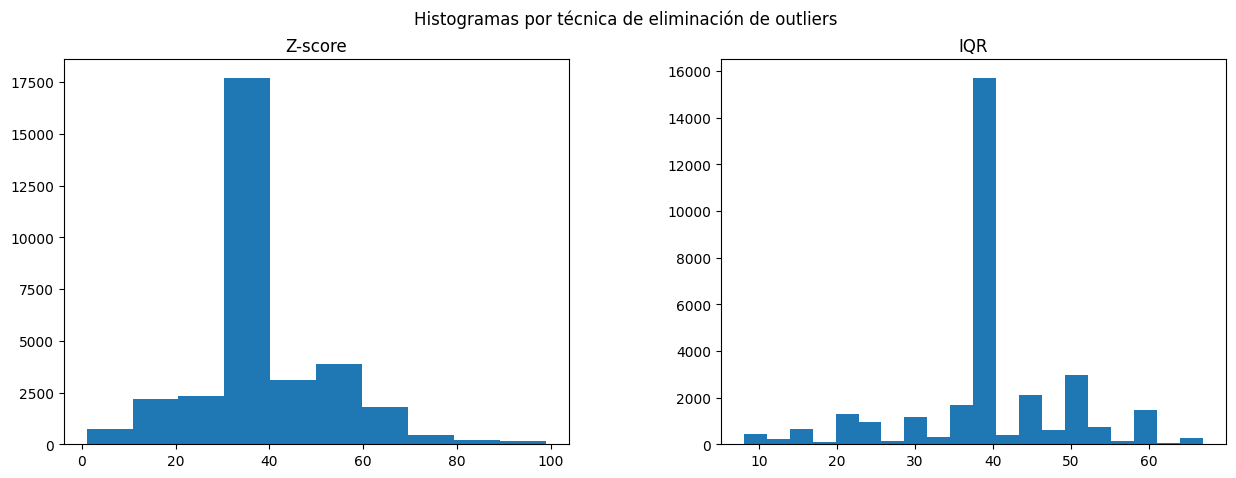

In [108]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15,5)
    )
fig.suptitle('Histogramas por técnica de eliminación de outliers')
df.hist('hours-per-week', grid=False, ax=ax[0])
ax[0].title.set_text('Z-score')
df3.hist('hours-per-week', bins=20, grid=False, ax=ax[1])
ax[1].title.set_text('IQR')

Analisis BOXPLOT de outliers multivariado comparativo entre numericas y variable objetivo

<Figure size 640x480 with 0 Axes>

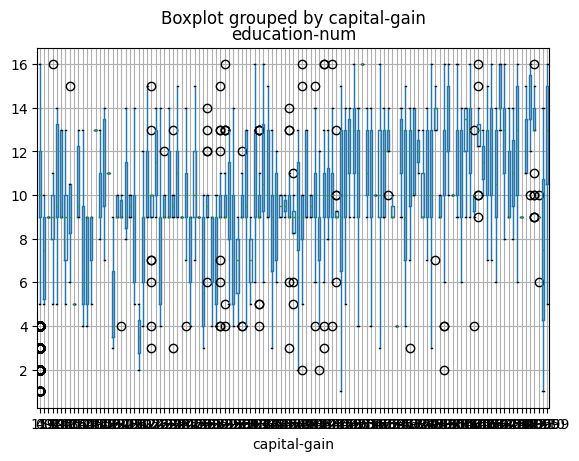

<Figure size 640x480 with 0 Axes>

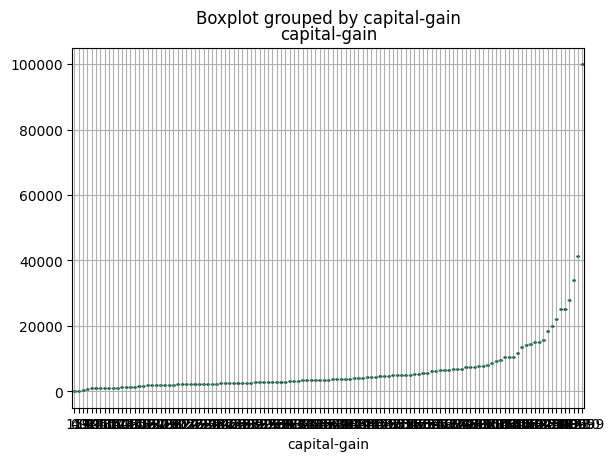

<Figure size 640x480 with 0 Axes>

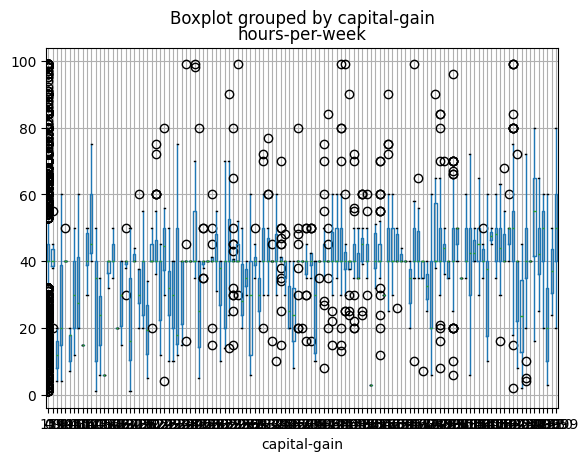

<Figure size 640x480 with 0 Axes>

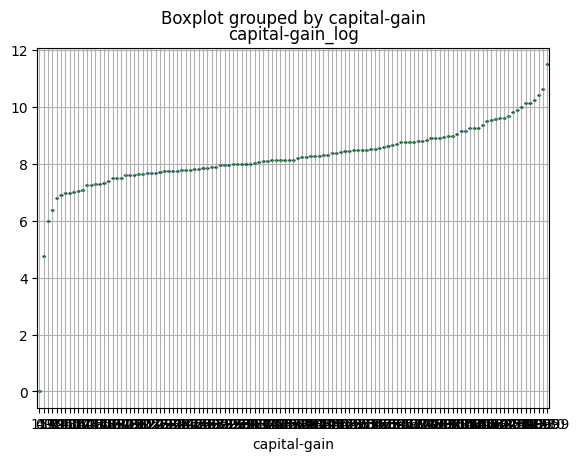

<Figure size 640x480 with 0 Axes>

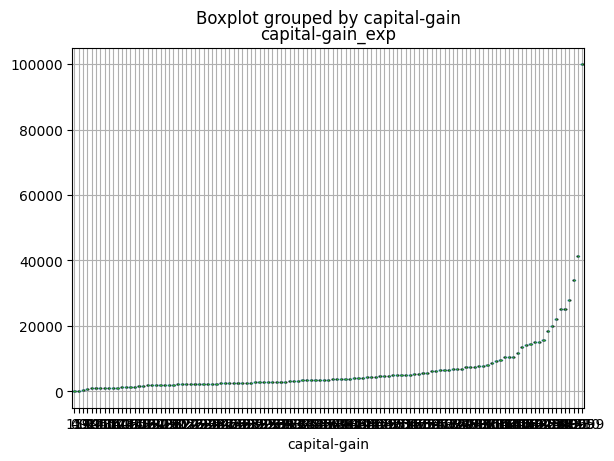

In [109]:

num_vars = df.select_dtypes(include='number').columns
for var in num_vars:
    plt.figure()
    df.boxplot(by='capital-gain', column=var)
    plt.title(var)
    plt.show()

In [110]:
df['hours-peer-week'] = df3['hours-per-week']

Ya solo faltaria aplicar las transformaciones correspondientes con el Column Transformer.

<h2>Analisis de variables Categoricas</h2>

In [111]:
df.describe(include='object').T

/tmp/ipykernel_280684/1760094569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
workclass,32537,9,Private,22673
education,32537,16,HS-grad,10494
marital-status,32537,7,Married-civ-spouse,14970
occupation,32537,15,Prof-specialty,4136
relationship,32537,6,Husband,13187
race,32537,5,White,27795
sex,32537,2,Male,21775
native-country,32537,42,United-States,29153
income,32537,2,<=50K,24698


De aqui que las variables education, occupation y native-country tengan alta cardinalidad. Veamos si hay alguna que no tenga efecto para poderla descartar

var_categoricas = df.select_dtypes(include="object").columns </br>
for var in var_categoricas:</br>
    tabla = pd.crosstab(df[var], df['capital-gain'], normalize='index')</br>
    tabla.plot(kind='bar', stacked=True)</br>
    plt.title(var)</br>
    plt.show() # no ejecuto este porque me llenan de graficas que al final no me sirvieron pa nada

In [112]:
var_categoricas = df.select_dtypes(include="object").columns </br>
for var in var_categoricas:<
    tabla = pd.crosstab(df[var], df['capital-gain'], normalize='index')
    tabla.plot(kind='bar', stacked=True)
    plt.title(var)
    plt.show()

SyntaxError: invalid syntax (3904546325.py, line 1)

Si se hubiera podido determinar que alguna de estas no era relevante se eliminaba, como no, entonces solo trabajaremos en la reduccion de la cardinalidad de las de alta cardinalidad en el column transformer.

<h2>Column transformer</h2>

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['capital-gain'], axis=1)
y = df['capital-gain']
#primero siempre se dividen los datos en entrenamiento y prueba, luego se hace el preprocesamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.7)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (22775, 12)
Tamaño del conjunto de prueba es: (9762, 12)


In [ ]:
df['education'].unique() #para ver los valores unicos de la variable education

<StringArray>
[   ' Bachelors',      ' HS-grad',         ' 11th',      ' Masters',
          ' 9th', ' Some-college',   ' Assoc-acdm',    ' Assoc-voc',
      ' 7th-8th',    ' Doctorate',  ' Prof-school',      ' 5th-6th',
         ' 10th',      ' 1st-4th',    ' Preschool',         ' 12th']
Length: 16, dtype: str

In [ ]:
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
    StandardScaler,
    TargetEncoder
)

ss = StandardScaler() 
pt = PowerTransformer()
orden_education = [' Preschool', ' 1st-4th', ' 5th-6th', ' 7th-8th', ' 9th', ' 10th', ' 11th', ' 12th',
         ' HS-grad',' Some-college', ' Assoc-acdm', ' Assoc-voc', ' Bachelors', ' Masters',
         ' Prof-school', ' Doctorate']
orden_relationship = [ ' Not-in-family',        ' Husband',           ' Wife',      ' Own-child',
      ' Unmarried', ' Other-relative']
orden_maritalstatus = [' Married-civ-spouse', ' Divorced', ' Never-married', ' Separated', ' Widowed', ' Married-spouse-absent', ' Married-AF-spouse']

ore_education = OrdinalEncoder(categories=[orden_education], dtype='int', max_categories=6) # aqui reducimos a solo 6 categorias las de alta cardinalidad ordinales
ore_relationship = OrdinalEncoder(categories=[orden_relationship], dtype='int')
ore_maritalstatus = OrdinalEncoder(categories=[orden_maritalstatus], dtype='int') 
ohe = OneHotEncoder(sparse_output=False, drop='first') 
oheAC = OneHotEncoder(sparse_output=False, drop='first', max_categories=6) # aqui reducimos a solo 6 categorias las de alta cardinalidad nominales


In [ ]:
from sklearn.compose import ColumnTransformer

#Aqui se define el preprocesador completo, indicando qué preprocesador se aplicará a cada variable. 
# Las demás columnas se descartan con remainder='drop'

preprocessor = ColumnTransformer(transformers=[
    ('power_transformer', pt, ['hours-per-week']), 
    ('std_od_relationship', ore_relationship, ['relationship']),
    ('od_education_ac', ore_education, ['education']),
    ('std_od_maritalstatus', ore_maritalstatus, ['marital-status']),
    ('std_one_hot_encoder', ohe, ['race','sex','workclass']),
    ('one_hot_encoder_ac', oheAC, ['occupation', 'native-country'])
    ], remainder='drop') # Las demás columnas se descartan

In [ ]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('power_transformer', ...), ('std_od_relationship', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``tran